In [120]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

# 确保本地包可 import（在 repo 根目录 or 子目录里都能跑）
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "alpha_lab").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from alpha_lab.config import get_paths, ensure_dir
paths = get_paths()
ensure_dir(paths.data_raw_dir)


PosixPath('/Users/shusheng/PythonProjects/alpha_lab/data/raw')

In [121]:
# 导入模块（核心代码已修复，无需 monkey patch）
import numpy as np
import pandas as pd

import alpha_lab.portfolio.rebalance as reb
import alpha_lab.backtest.engine as eng
import alpha_lab.metrics.drawdown as dd
from alpha_lab.utils.dates import parse_date, generate_rebalance_dates

# 注意：之前这里有大量 monkey patch 代码来修复以下问题：
# 1. _generate_rebalance_schedule_fixed - 现已在 rebalance.py 中修复
# 2. _simulate_portfolio_fixed - 现已在 engine.py 中修复（日期比较和边界条件）
# 3. _compute_drawdown_series_fixed - 现已在 drawdown.py 中修复
# 4. _compute_drawdown_metrics_fixed - 现已在 drawdown.py 中修复
# 
# 这些修复已合并到核心代码中，此 cell 现在只需要导入模块即可

In [122]:
USE_SYNTHETIC = False# 如果你有真实 CSV，改成 False
csv_path = paths.data_raw_dir / "close.csv"


if USE_SYNTHETIC or not csv_path.exists():
    rng = np.random.default_rng(7)
    dates = pd.date_range("2022-01-03", periods=260, freq="B")
    tickers = ["AAA", "BBB", "CCC", "DDD", "EEE"]

    prices = pd.DataFrame(
        100 * np.exp(np.cumsum(rng.normal(0, 0.01, (len(dates), len(tickers))), axis=0)),
        index=dates,
        columns=tickers,
    )
    prices.index.name = "date"
    prices.reset_index().to_csv(csv_path, index=False)

    print("wrote", csv_path)
else:
    print("use existing", csv_path)


use existing /Users/shusheng/PythonProjects/alpha_lab/data/raw/close.csv


In [123]:
# 重新加载模块以确保使用最新修复的代码
import importlib
import sys

# 重新加载核心模块
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('alpha_lab'):
        try:
            importlib.reload(sys.modules[mod_name])
        except:
            pass

from alpha_lab.data.loader import load_prices
from alpha_lab.factors.momentum import momentum
from alpha_lab.factors.transform import zscore, winsorize
from alpha_lab.portfolio.rebalance import generate_rebalance_schedule
from alpha_lab.portfolio.weighting import top_k_long_only, top_k_long_short

# 从 CSV 文件读取 tickers 和日期范围
prices_df = pd.read_csv(csv_path, parse_dates=["Date"], index_col="Date")
tickers = prices_df.columns.tolist()
dates = prices_df.index

start_ts = dates.min()
end_ts = dates.max()

# 使用新的 csv_file 参数指定要读取的文件
prices_loaded = load_prices(
    universe=tickers,
    start_date=start_ts,
    end_date=end_ts,
    field="close",
    source="csv",
    align_dates=True,
    csv_file="random_sampled_stocks_adj_close.csv",  # 直接指定文件名
)

print(f"✓ Loaded prices: {prices_loaded.shape} (dates × tickers)")
print(f"  Date range: {prices_loaded.index.min().date()} to {prices_loaded.index.max().date()}")
print(f"  Tickers (first 5): {prices_loaded.columns.tolist()[:5]}")
print(f"  Sample prices:\n{prices_loaded.iloc[:3, :3]}")

# 计算因子和权重
factor = momentum(prices_loaded, lookback=5, lag=1, method="log")
factor = winsorize(factor)
rebalance_dates = generate_rebalance_schedule(
    trading_calendar=prices_loaded.index,
    start_date=start_ts,
    end_date=end_ts,
    freq="M",
)

# 使用 reindex 而不是 loc 来处理日期对齐问题
factor_reb = factor.reindex(rebalance_dates).dropna(how='all')
weights = top_k_long_only(factor_reb, 0.2)

print(f"\n✓ Factor shape: {factor.shape}")
print(f"✓ Rebalance dates: {len(rebalance_dates)} dates")
print(f"✓ Weights shape: {weights.shape}")
print(f"  Sample rebalance dates: {rebalance_dates[:3].tolist()}")

2026-01-03 13:55:24 | INFO     | alpha_lab.data.loader | Loading close prices: 222 tickers, 2009-09-29 to 2025-12-16
2026-01-03 13:55:24 | WARNING  | alpha_lab.data.loader | Missing 2 tickers
2026-01-03 13:55:24 | INFO     | alpha_lab.data.loader | Loaded: 3456 days x 222 assets
✓ Loaded prices: (3456, 222) (dates × tickers)
  Date range: 2009-10-05 to 2025-12-16
  Tickers (first 5): ['PLPC', 'REGN', 'SEVN', 'NOVT', 'LPTH']
  Sample prices:
                 PLPC       REGN      SEVN
2009-10-05  31.122704  18.298515  4.925210
2009-10-19  31.543493  18.606804  5.382902
2009-10-30  31.155071  15.613405  5.089289
2026-01-03 13:55:24 | INFO     | alpha_lab.portfolio.rebalance | Generated 195 rebalance dates (freq=M)

✓ Factor shape: (3456, 222)
✓ Rebalance dates: 195 dates
✓ Weights shape: (193, 222)
  Sample rebalance dates: [Timestamp('2009-10-30 00:00:00'), Timestamp('2009-11-30 00:00:00'), Timestamp('2009-12-28 00:00:00')]


In [124]:
from alpha_lab.backtest.engine import run_backtest
from alpha_lab.config.backtest import BacktestConfig
from alpha_lab.metrics.summary import generate_backtest_summary

cfg = BacktestConfig(
    start_date=start_ts.date().isoformat(),
    end_date=end_ts.date().isoformat(),
    rebalance_freq="M",
    initial_cash=1_000_000.0,
    commission_bps=0.1,
    slippage_bps=0.1,
    price_field="close",
    max_turnover=0.8,
    execution_delay_days=0,
)



result = run_backtest(weights=weights, prices=prices_loaded, config=cfg)
metrics = generate_backtest_summary(result, as_dataframe=False)

metrics


2026-01-03 13:55:24 | INFO     | alpha_lab.backtest.engine | Running backtest: 2009-09-29 to 2025-12-16, freq=M, initial_cash=1,000,000
2026-01-03 13:55:26 | INFO     | alpha_lab.backtest.engine | Backtest complete: 3456 days, final equity=6,493,084
2026-01-03 13:55:26 | INFO     | alpha_lab.metrics.summary | Generating metrics summary


{'total_return': np.float64(5.4930844291670855),
 'cagr': np.float64(0.14619462864963517),
 'annualized_vol': np.float64(0.23496696248465831),
 'sharpe_ratio': np.float64(0.698446459298625),
 'win_rate': np.float64(0.5274884259259259),
 'best_day': np.float64(0.1334896651797408),
 'worst_day': np.float64(-0.1315761348046588),
 'n_periods': 3456,
 'max_drawdown': np.float64(0.462429918205592),
 'avg_drawdown': np.float64(0.1113976591495145),
 'current_drawdown': np.float64(0.03393920175961604),
 'max_drawdown_duration': 1191}

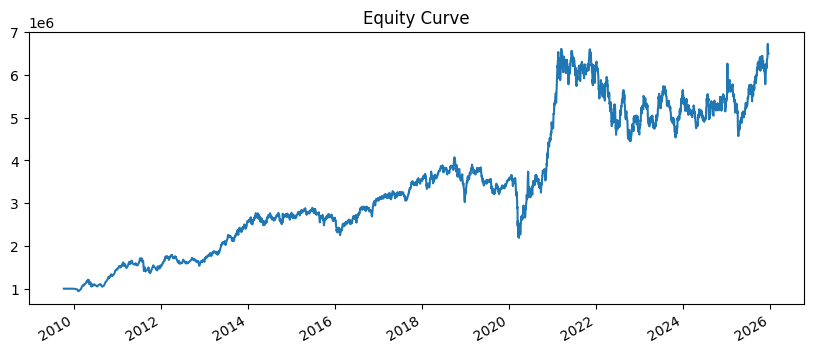

In [125]:
import matplotlib.pyplot as plt

result.equity_curve.plot(figsize=(10, 4), title="Equity Curve")
plt.show()
